<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/Proyecto-Final-261554/Proyecto_Analisis_Predictivo_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Análisis Predictivo

[Análisis de Bank Marketing]


**Etapas: Preprocesamiento (normalización, codificación de variables categóricos, selección de características, clases no balanceadas), optimización de hiperparámetros y resultados de clasificación**

Nombre: [Juan Francisco Gámez Cortés]

Matrícula: 261554

Fecha: [22/11/2025]

In [1]:
# Montar google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **1. Introducción**

- Descripción del problema: ¿Qué queremos analizar o predecir?

Requerimos analizar el conjunto de datos de una campaña de marketing bancario para predecir si un cliente se suscribirá aun deposito.

- Objetivo del análisis: ¿Qué impacto tendrá este análisis?

El objetivo es construir un modelo predictivo que determine si un cliente se suscribirá o no a un deposito, lo que apoyará en la toma de desiciones del Banco para sus campañas de marketing
- Fuente de datos: ¿De dónde provienen los datos?

La fuente de datos proviene de la siguiente URL: https://archive.ics.uci.edu/dataset/222/bank+marketing

Esta basada en datos de llamadas telefónicas para una campaña de marketing de una institucion bancaria de Portugal.

In [92]:
# Bibliotecas a utilizar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotly import tools
import plotly.figure_factory as ff
import plotly.graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
from matplotlib.ticker import MaxNLocator
import seaborn as sns

from statsmodels.stats.weightstats import DescrStatsW
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, make_scorer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, RandomizedSearchCV, GridSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import time

from sklearn.cluster import KMeans
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE




# **2. Captura y Carga de Datos**

- Explicación de la fuente de datos: ¿Cuáles son las fuentes de datos?

El dataset proviene de https://archive.ics.uci.edu/dataset/222/bank+marketing
- ¿Qué formato tienen los datos (CSV, SQL, API, etc.)?

El formato del dataset es un CSV separado por `;`
- ¿Cuántas observaciones y variables contiene el dataset?

`Dimensiones del dataset`

Cantidad de filas:  45211

Cantidad de columnas:  17
- Explicación sobre problemas en la carga de Datos y el Código para la carga de datos desde archivos (bibiotecas, etc.)
En la carga de datos solo tener en cuenta que el caracter de separación es `;`

In [3]:
# Cargar el dataset de Bank Marketing
df_orig = pd.read_csv('/content/drive/MyDrive/Proyecto-Predictivo/bank-full.csv', sep=';')
df = df_orig.copy()

#**3.Transformación y Preprocesamiento - Data Wrangling**

- Identificación de Tipos de Datos

Podemos observar los siguientes tipos de datos: 7 son int64 y 10 tipo object
- Cantidad de Valores nulos

No se encontraron datos nulos por lo que se cuenta con un dataset limpio para el análisis
- Explicación sobre cada una de las problemáticas encontradas, las soluciones y el código

Se identifica que el dataset contiene variables categoricas que deberán ser codificadas para el análisis respectivo y creación del modelo. Así mismo, se identifica que la variable objetivo se encuentra desbalanceada por lo cual se deberá realizar el tratamiento respectivo.

In [4]:
#Dimesiones del dataset
filas, columnas = df_orig.shape
print("---Dimensiones--- ")
print(f"Cantidad de filas: ",{filas})
print(f"Cantidad de columnas: ",{columnas})

#Tipos de datos del dataset
print("\n---Tipos de datos--- ")
print(df_orig.info())
print("\n")
print("---Primeras filas--- ")
print(df_orig.head())
print("\n")
print("---Estadisticas descriptivas--- ")
print(df_orig.describe())


---Dimensiones--- 
Cantidad de filas:  {45211}
Cantidad de columnas:  {17}

---Tipos de datos--- 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
N

In [5]:
# Revisión de datos nulos
print("Datos nulos\n",df_orig.isna().sum())

# Revisión de datos Duplicados
print("\nDatos Duplicados",df_orig.duplicated().sum())

Datos nulos
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Datos Duplicados 0


In [6]:
# Distribución de las clases
print("Distribución de clases :\n")
for col in df_orig.columns:
    print(f"\n--- {col} ---")
    print(df_orig[col].value_counts())

Distribución de clases :


--- age ---
age
32    2085
31    1996
33    1972
34    1930
35    1894
      ... 
95       2
93       2
92       2
88       2
94       1
Name: count, Length: 77, dtype: int64

--- job ---
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

--- marital ---
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

--- education ---
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

--- default ---
default
no     44396
yes      815
Name: count, dtype: int64

--- balance ---
balance
0        3514
1         195
2         156
4         139
3         134
         ... 
14204       1
8205        1
9710        1
7038        1
4416        1

## Realizamos la conversión de columnas al tipo categorico correspondiente

In [7]:
# Conversion de columnas a tipo categorico
print(df['job'].unique())
df['job'] = df['job'].astype('category')

print(df['marital'].unique())
df['marital'] = df['marital'].astype('category')

print(df['education'].unique())
df['education'] = df['education'].astype('category')

print(df['contact'].unique())
df['contact'] = df['contact'].astype('category')

print(df['poutcome'].unique())
df['poutcome'] = df['poutcome'].astype('category')



['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
['married' 'single' 'divorced']
['tertiary' 'secondary' 'unknown' 'primary']
['unknown' 'cellular' 'telephone']
['unknown' 'failure' 'other' 'success']


# **4. Análisis Descriptivo de Datos**

- Preguntas a responder con el AD

¿El nivel educativo del cliente es un factor determinante para aceptar la suscripción?
¿El estado civil influye en la suscripción?
¿Como influye el saldo promedio anual en si el cliente acepta o no la suscripción?


## Explicación de Estadísticas Básicas Aplicadas, Visualización de Datos con Gráficos, y Resumen de las respuestas

## Distribuciones de las variables


In [71]:
suscribed_df = df_orig.loc[df_orig['y'] == 'yes']

occupations = df_orig['job'].unique().tolist()

# Obtener el saldo por ocupación
management = suscribed_df['age'].loc[suscribed_df['job'] == 'management'].values
technician = suscribed_df['age'].loc[suscribed_df['job'] == 'technician'].values
services = suscribed_df['age'].loc[suscribed_df['job'] == 'services'].values
retired = suscribed_df['age'].loc[suscribed_df['job'] == 'retired'].values
blue_collar = suscribed_df['age'].loc[suscribed_df['job'] == 'blue-collar'].values
unemployed = suscribed_df['age'].loc[suscribed_df['job'] == 'unemployed'].values
entrepreneur = suscribed_df['age'].loc[suscribed_df['job'] == 'entrepreneur'].values
housemaid = suscribed_df['age'].loc[suscribed_df['job'] == 'housemaid'].values
self_employed = suscribed_df['age'].loc[suscribed_df['job'] == 'self-employed'].values
student = suscribed_df['age'].loc[suscribed_df['job'] == 'student'].values
admin = suscribed_df['age'].loc[suscribed_df['job'] == 'admin.'].values
unknown = suscribed_df['age'].loc[suscribed_df['job'] == 'unknown'].values



ages = [management, technician, services, retired, blue_collar, unemployed,
         entrepreneur, housemaid, self_employed, student, unknown]

colors = ['rgba(93, 164, 214, 0.5)', 'rgba(255, 144, 14, 0.5)',
          'rgba(44, 160, 101, 0.5)', 'rgba(255, 65, 54, 0.5)',
          'rgba(207, 114, 255, 0.5)', 'rgba(127, 96, 0, 0.5)',
          'rgba(229, 126, 56, 0.5)', 'rgba(229, 56, 56, 0.5)',
          'rgba(174, 229, 56, 0.5)', 'rgba(229, 56, 56, 0.5)',
          'rgba(93, 164, 214, 0.5)', 'rgba(255, 144, 14, 0.5)']

traces = []

for xd, yd, cls in zip(occupations, ages, colors):
        traces.append(go.Box(
            y=yd,
            name=xd,
            boxpoints='all',
            jitter=0.5,
            whiskerwidth=0.2,
            fillcolor=cls,
            marker=dict(
                size=2,
            ),
            line=dict(width=1),
        ))

layout = go.Layout(
    title='Distribución de Edades por Ocupación',
    yaxis=dict(
        autorange=True,
        showgrid=True,
        zeroline=True,
        dtick=5,
        gridcolor='rgb(255, 255, 255)',
        gridwidth=1,
        zerolinecolor='rgb(255, 255, 255)',
        zerolinewidth=2,
    ),
    margin=dict(
        l=40,
        r=30,
        b=80,
        t=100,
    ),
    paper_bgcolor='rgb(224,255,246)',
    plot_bgcolor='rgb(251,251,251)',
    showlegend=False
)

fig = go.Figure(data=traces, layout=layout)
iplot(fig)

## Mapeo de variables categoricas

In [9]:
#  Conversion a categorico con mapeo
month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

edu_map = {
    'unknown': 0,
    'primary': 1,
    'secondary': 2,
    'tertiary': 3
    }

# Mapeo de valores
df['month'] = df['month'].map(month_map)
df['education'] = df['education'].map(edu_map)

In [10]:
# Conversion de columnas mapeo a binarios
print(df['default'].unique())
print(df['housing'].unique())
print(df['loan'].unique())
print(df['y'].unique())

diccionario_binario = {'yes': 1, 'no': 0}

# Mapeo de valores
df['default'] = df['default'].map(diccionario_binario)
df['housing'] = df['housing'].map(diccionario_binario)
df['loan'] = df['loan'].map(diccionario_binario)
df['y'] = df['y'].map(diccionario_binario)


['no' 'yes']
['yes' 'no']
['no' 'yes']
['no' 'yes']


## Tipos de datos convertidos después del mapeo

In [11]:
# Nuevos Tipos de datos - Convertidos a categoricos o mapeos correspondientes
print("\n---Tipos de datos--- ")
print(df.info())


---Tipos de datos--- 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  int64   
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  int64   
 7   loan       45211 non-null  int64   
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  int64   
 11  duration   45211 non-null  int64   
 12  campaign   45211 non-null  int64   
 13  pdays      45211 non-null  int64   
 14  previous   45211 non-null  int64   
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  int64   
dtypes: category(5), int64(12)
memory usage: 4.4 MB
None


In [12]:
# Distribución de las clases
print("Distribución de clases :\n")
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

Distribución de clases :


--- age ---
age
32    2085
31    1996
33    1972
34    1930
35    1894
      ... 
95       2
93       2
92       2
88       2
94       1
Name: count, Length: 77, dtype: int64

--- job ---
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

--- marital ---
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

--- education ---
education
2    23202
3    13301
1     6851
0     1857
Name: count, dtype: int64

--- default ---
default
0    44396
1      815
Name: count, dtype: int64

--- balance ---
balance
0        3514
1         195
2         156
4         139
3         134
         ... 
14204       1
8205        1
9710        1
7038        1
4416        1
Name: count, Length: 7168, dtype: i

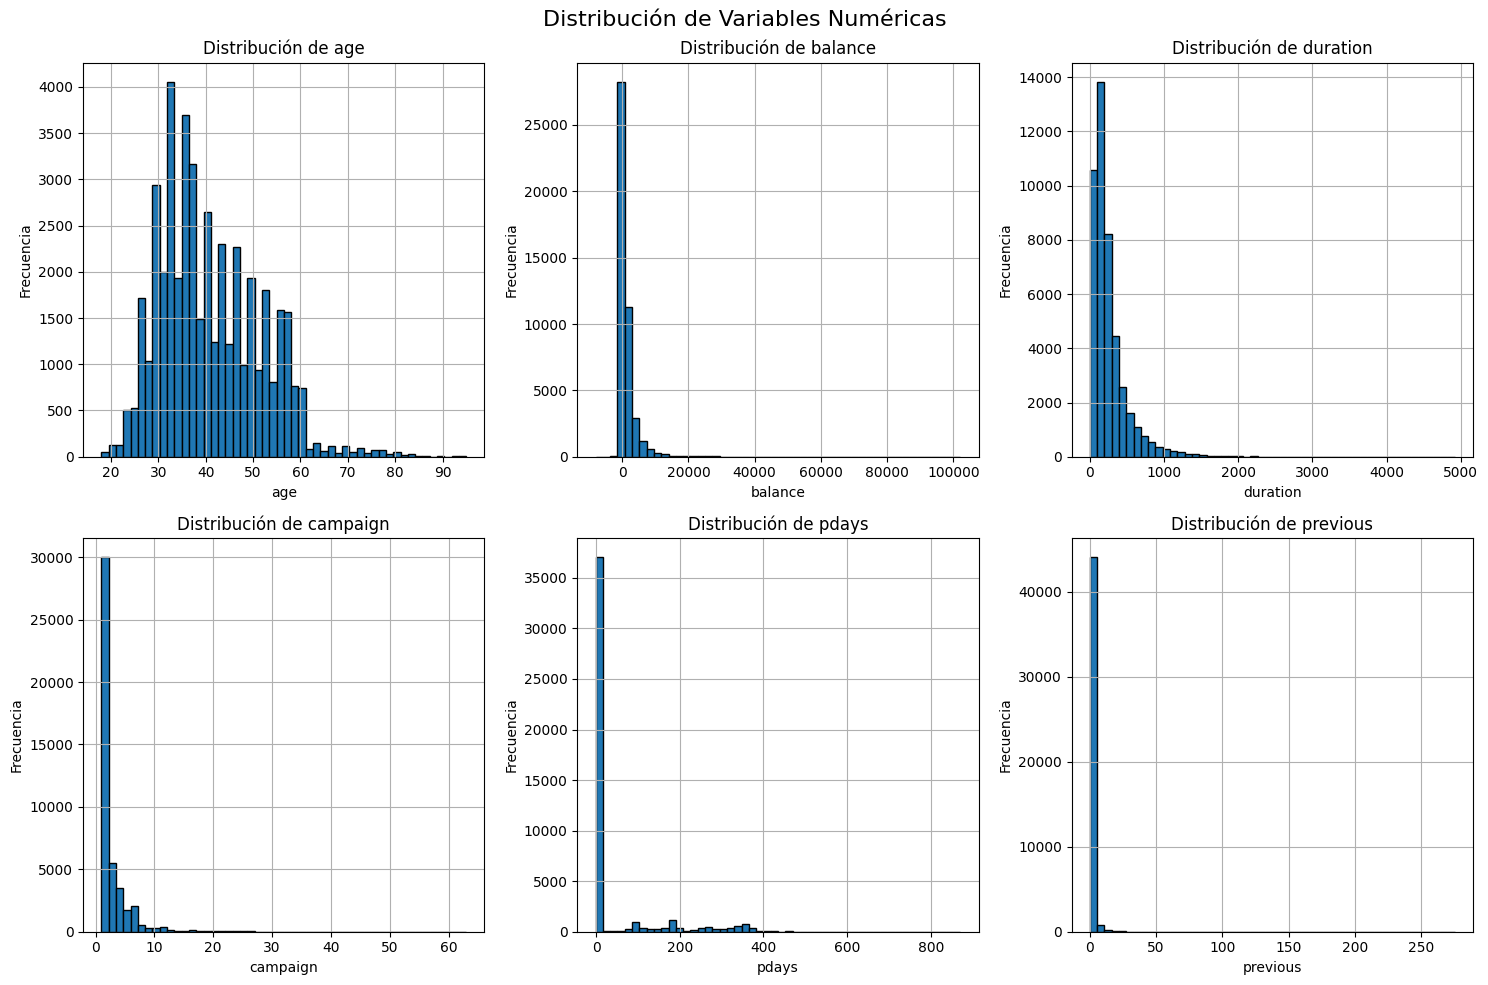

In [13]:
# Seleccionar solo las columnas numéricas
columnas_numericas = ['age','balance','duration','campaign','pdays','previous']
# Calcular el número de filas y columnas para el subplot
n = len(columnas_numericas)
nrows = 2
ncols = min(n, 3)
# Crear la figura y los subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16)
# Aplanar el array de ejes en caso de que sea 2D
axes = axes.flatten() if n > 3 else [axes]
# Crear histogramas para cada variable numérica
for i, col in enumerate(columnas_numericas):
 ax = axes[i]
 df[col].hist(ax=ax, bins=50, edgecolor='black')
 ax.set_title(f'Distribución de {col}')
 ax.set_xlabel(col)
 ax.set_ylabel('Frecuencia')
# Ocultar subplots vacíos si los hay
for j in range(i+1, len(axes)):
 fig.delaxes(axes[j])
plt.tight_layout()
plt.show()



- La Variable objetivo `y` se encuentra desbalanceada, por lo cual posteriormente definiremos una técnica para ajustar el desbalance

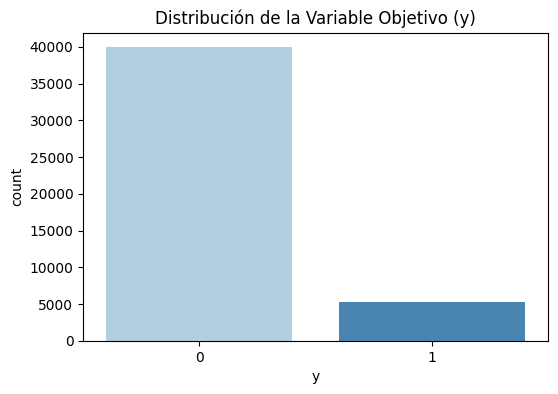

In [14]:
# Distribución de la Variable Objetivo Y
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, hue='y', legend=False, palette='Blues')
plt.title('Distribución de la Variable Objetivo (y)')
plt.show()

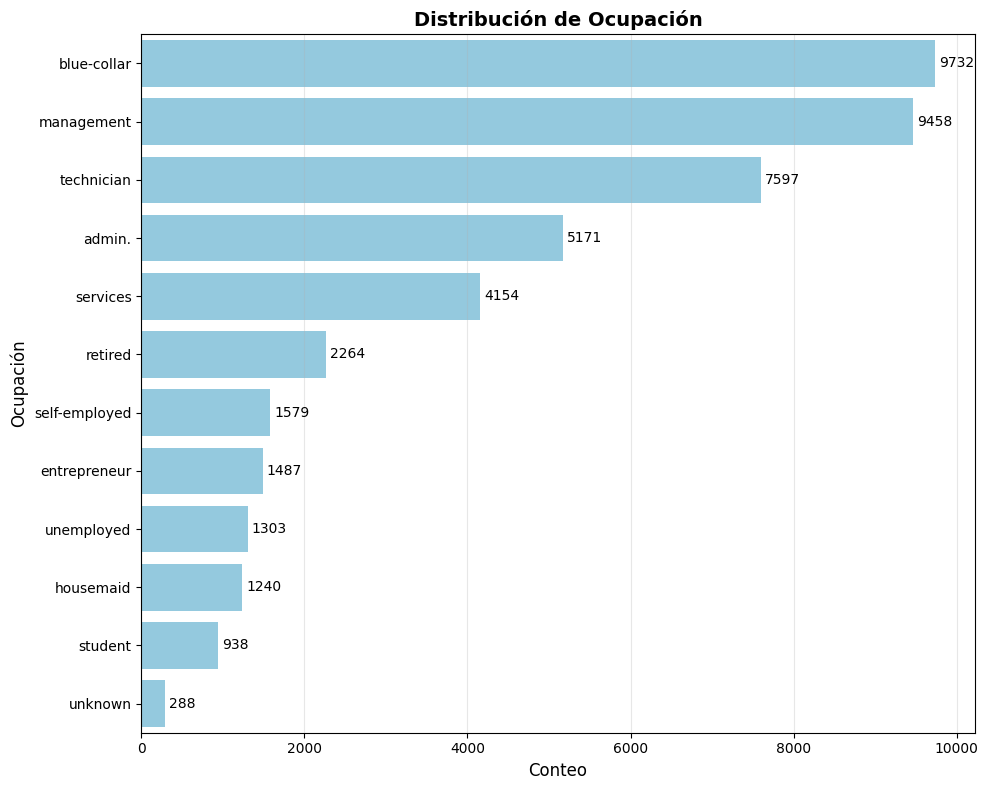

In [15]:
# Grafica de barras para Ocupación

plt.figure(figsize=(10, 8))

orden = df['job'].value_counts().index
ax = sns.countplot(data=df, y='job', color="skyblue", order=orden)

# Etiquetas de datos
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.title("Distribución de Ocupación", fontsize=14, weight='bold')
plt.xlabel("Conteo", fontsize=12)
plt.ylabel("Ocupación", fontsize=12)

plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

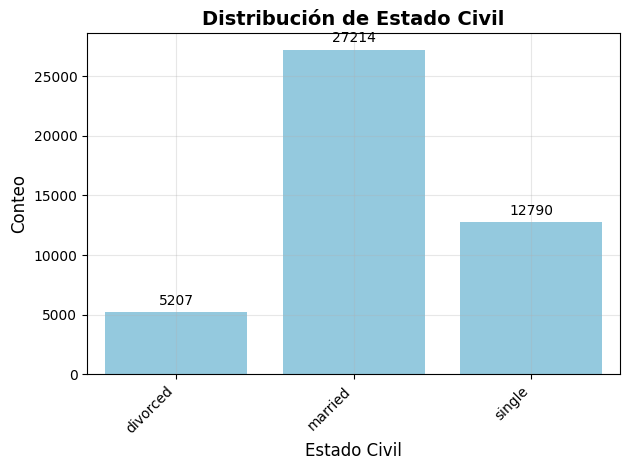

In [16]:
# Gráfica de barras para Estado Civil

ax = sns.countplot(data=df, x='marital', color="skyblue")

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.title("Distribución de Estado Civil", fontsize=14, weight='bold')
plt.xlabel("Estado Civil", fontsize=12)
plt.ylabel("Conteo", fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

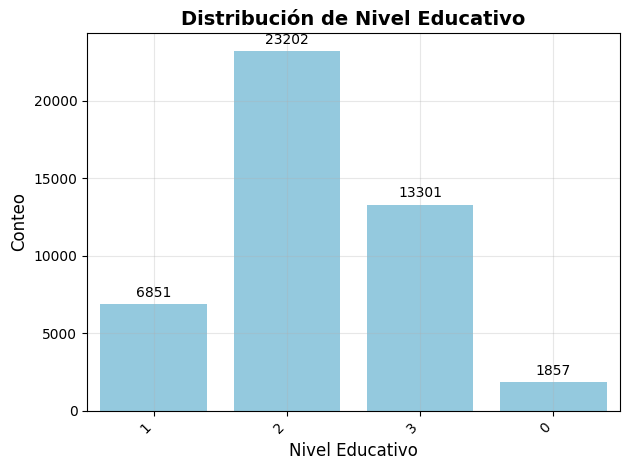

In [17]:
# Gráfica de barras para Nivel Educativo
ax = sns.countplot(data=df, x='education', color="skyblue")

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.title("Distribución de Nivel Educativo", fontsize=14, weight='bold')
plt.xlabel("Nivel Educativo", fontsize=12)
plt.ylabel("Conteo", fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Análisis de outliers

RESUMEN DE OUTLIERS (Criterio de Tukey)

VARIABLE: DURATION

Total de observaciones: 45,211

Outliers inferiores: 0

Outliers superiores: 3,235

Total de outliers: 3,235 (7.16%)

Estadísticas de Duration
Media: 258.16 segundos
Mediana: 180.00 segundos
Desviación Estándar: 257.53 segundos


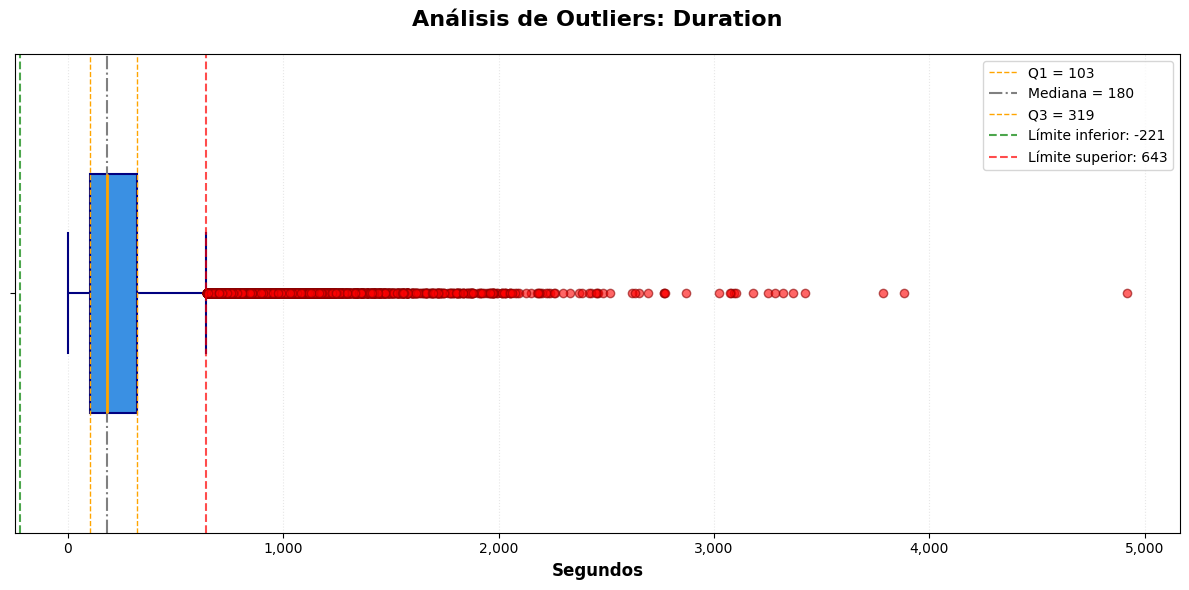


RESUMEN DE OUTLIERS (Criterio de Tukey)
Total de observaciones: 45,211
Outliers inferiores: 0
Outliers superiores: 3,235
Total de outliers: 3,235 (7.16%)
Rango normal: -221 - 643 segundos
Rango de outliers superiores: > 643 segundos


In [18]:
# Establecer tamaño del gráfico
plt.figure(figsize=(12, 6))

variable = df['duration']

# Calcular estadísticas descriptivas
mean_value = variable.mean()
median_value = variable.median()
std_value = variable.std()

print("Estadísticas de Duration")
print(f"Media: {mean_value:,.2f} segundos")
print(f"Mediana: {median_value:,.2f} segundos")
print(f"Desviación Estándar: {std_value:,.2f} segundos")

# Calcular estadísticas para los outliers con criterio de Tukey IQR
Q1 = variable.quantile(0.25)
Q3 = variable.quantile(0.75)
mediana = median_value

IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Contabilizar los outliers
outliers_inferiores = (variable < limite_inferior).sum()
outliers_superiores = (variable > limite_superior).sum()
total_outliers = outliers_inferiores + outliers_superiores
porcentaje_outliers = (total_outliers / len(df)) * 100

# Crear el boxplot
box = sns.boxplot(
    x=variable,
    orient='h',
    color='dodgerblue',
    width=0.5,
    flierprops={
        "marker": "o",
        "markersize": 6,
        "markerfacecolor": "red",
        "markeredgecolor": "darkred",
        "alpha": 0.6
    },
    boxprops={"edgecolor": "navy", "linewidth": 1.5},
    medianprops={"color": "orange", "linewidth": 2},
    whiskerprops={"color": "navy", "linewidth": 1.5},
    capprops={"color": "navy", "linewidth": 1.5}
)

# Añadir líneas de referencia para los quartiles y los límites
plt.axvline(Q1, color="orange", linestyle="--", linewidth=1, label=f"Q1 = {Q1:.0f}")
plt.axvline(mediana, color="grey", linestyle="-.", linewidth=1.5, label=f"Mediana = {mediana:.0f}")
plt.axvline(Q3, color="orange", linestyle="--", linewidth=1, label=f"Q3 = {Q3:.0f}")
plt.axvline(limite_inferior, color='green', linestyle='--', linewidth=1.5,
            label=f'Límite inferior: {limite_inferior:,.0f}', alpha=0.7)
plt.axvline(limite_superior, color='red', linestyle='--', linewidth=1.5,
            label=f'Límite superior: {limite_superior:,.0f}', alpha=0.7)

# Etiquetas de Títulos
plt.title('Análisis de Outliers: Duration', fontsize=16, weight='bold', pad=20)
plt.xlabel('Segundos', fontsize=12, weight='bold')

# Formatear el eje con separadores de miles
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.grid(axis='x', alpha=0.3, linestyle=':', linewidth=0.8)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# Imprimir resumen de outliers identificados
print("\nRESUMEN DE OUTLIERS (Criterio de Tukey)")
print(f"Total de observaciones: {len(df):,}")
print(f"Outliers inferiores: {outliers_inferiores:,}")
print(f"Outliers superiores: {outliers_superiores:,}")
print(f"Total de outliers: {total_outliers:,} ({porcentaje_outliers:.2f}%)")
print(f"Rango normal: {limite_inferior:,.0f} - {limite_superior:,.0f} segundos")
print(f"Rango de outliers superiores: > {limite_superior:,.0f} segundos")
if outliers_inferiores > 0:
    print(f"Rango de outliers inferiores: < {limite_inferior:,.0f} segundos")

### Análisis de outliers

RESUMEN DE OUTLIERS (Criterio de Tukey)

VARIABLE: CAMPAIGN

Total de observaciones: 45,211

Outliers inferiores: 0

Outliers superiores: 3,064

Total de outliers: 3,064 (6.78%)

Estadísticas de Campaign
Media: 2.76 contactos
Mediana: 2.00 contactos
Desviación Estándar: 3.10 contactos


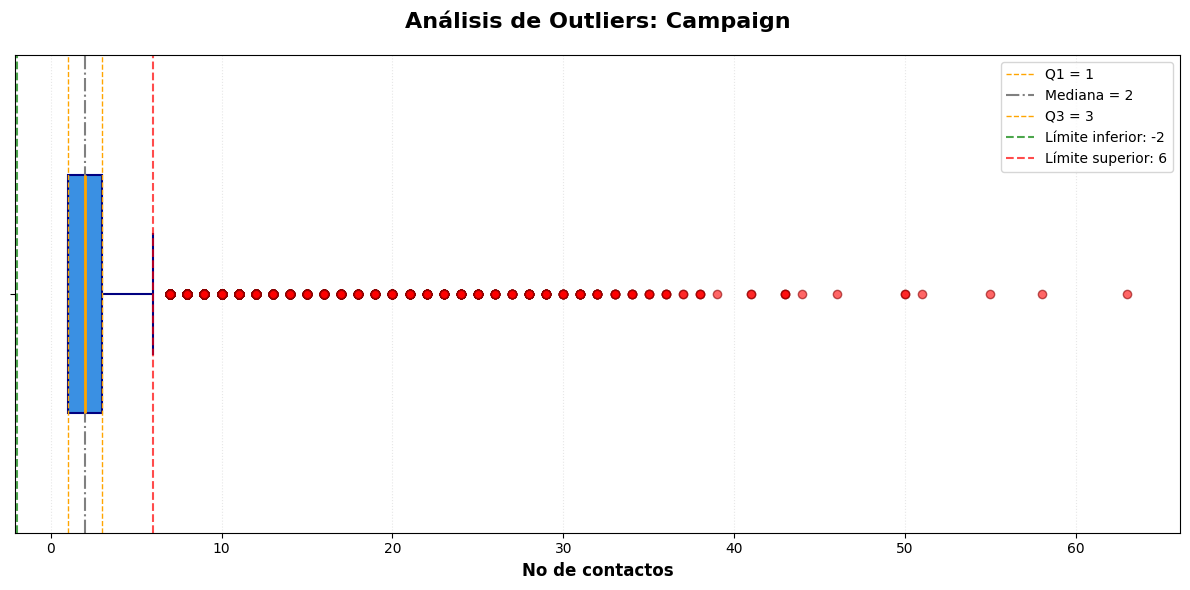


RESUMEN DE OUTLIERS (Criterio de Tukey)
Total de observaciones: 45,211
Outliers inferiores: 0
Outliers superiores: 3,064
Total de outliers: 3,064 (6.78%)
Rango normal: -2 - 6 contactos
Rango de outliers superiores: > 6 contactos


In [19]:
# Establecer tamaño del gráfico
plt.figure(figsize=(12, 6))

variable = df['campaign']

# Calcular estadísticas descriptivas
mean_value = variable.mean()
median_value = variable.median()
std_value = variable.std()

print("Estadísticas de Campaign")
print(f"Media: {mean_value:,.2f} contactos")
print(f"Mediana: {median_value:,.2f} contactos")
print(f"Desviación Estándar: {std_value:,.2f} contactos")

# Calcular estadísticas para los outliers con criterio de Tukey IQR
Q1 = variable.quantile(0.25)
Q3 = variable.quantile(0.75)
mediana = median_value

IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Contabilizar los outliers
outliers_inferiores = (variable < limite_inferior).sum()
outliers_superiores = (variable > limite_superior).sum()
total_outliers = outliers_inferiores + outliers_superiores
porcentaje_outliers = (total_outliers / len(df)) * 100

# Crear el boxplot
box = sns.boxplot(
    x=variable,
    orient='h',
    color='dodgerblue',
    width=0.5,
    flierprops={
        "marker": "o",
        "markersize": 6,
        "markerfacecolor": "red",
        "markeredgecolor": "darkred",
        "alpha": 0.6
    },
    boxprops={"edgecolor": "navy", "linewidth": 1.5},
    medianprops={"color": "orange", "linewidth": 2},
    whiskerprops={"color": "navy", "linewidth": 1.5},
    capprops={"color": "navy", "linewidth": 1.5}
)

# Añadir líneas de referencia para los quartiles y los límites
plt.axvline(Q1, color="orange", linestyle="--", linewidth=1, label=f"Q1 = {Q1:.0f}")
plt.axvline(mediana, color="grey", linestyle="-.", linewidth=1.5, label=f"Mediana = {mediana:.0f}")
plt.axvline(Q3, color="orange", linestyle="--", linewidth=1, label=f"Q3 = {Q3:.0f}")
plt.axvline(limite_inferior, color='green', linestyle='--', linewidth=1.5,
            label=f'Límite inferior: {limite_inferior:,.0f}', alpha=0.7)
plt.axvline(limite_superior, color='red', linestyle='--', linewidth=1.5,
            label=f'Límite superior: {limite_superior:,.0f}', alpha=0.7)

# Etiquetas de Títulos
plt.title('Análisis de Outliers: Campaign', fontsize=16, weight='bold', pad=20)
plt.xlabel('No de contactos', fontsize=12, weight='bold')

# Formatear el eje con separadores de miles
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.grid(axis='x', alpha=0.3, linestyle=':', linewidth=0.8)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# Imprimir resumen de outliers identificados
print("\nRESUMEN DE OUTLIERS (Criterio de Tukey)")
print(f"Total de observaciones: {len(df):,}")
print(f"Outliers inferiores: {outliers_inferiores:,}")
print(f"Outliers superiores: {outliers_superiores:,}")
print(f"Total de outliers: {total_outliers:,} ({porcentaje_outliers:.2f}%)")
print(f"Rango normal: {limite_inferior:,.0f} - {limite_superior:,.0f} contactos")
print(f"Rango de outliers superiores: > {limite_superior:,.0f} contactos")
if outliers_inferiores > 0:
    print(f"Rango de outliers inferiores: < {limite_inferior:,.0f} contactos")

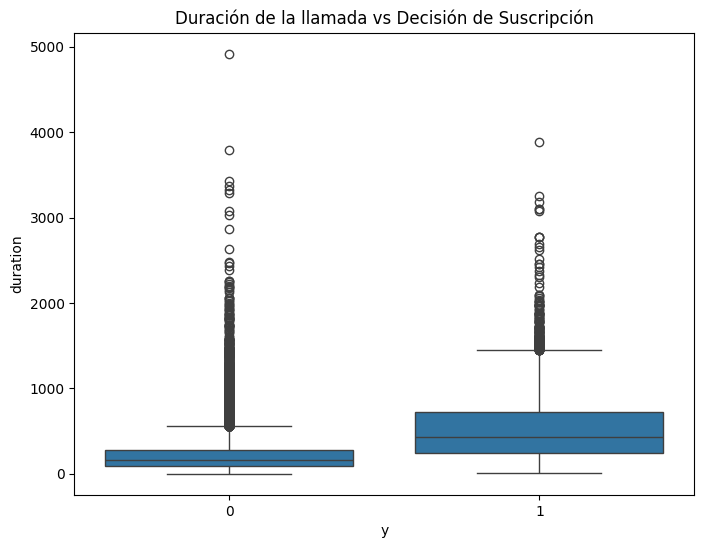

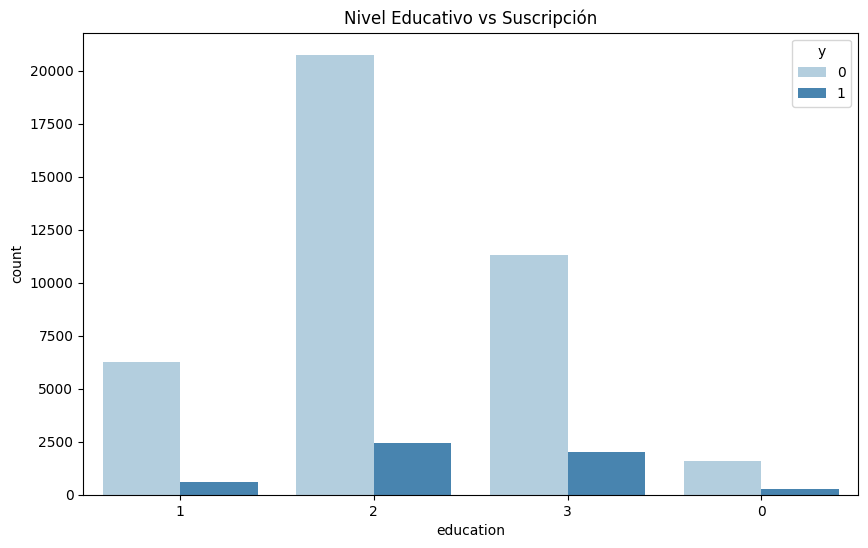

In [20]:
# Relación Duración vs Suscripción
# Hipótesis: Llamadas más largas resultan en éxito.
plt.figure(figsize=(8, 6))
sns.boxplot(x='y', y='duration', data=df)
plt.title('Duración de la llamada vs Decisión de Suscripción')
plt.show()

# Relación Educación vs Suscripción
plt.figure(figsize=(10, 6))
sns.countplot(x='education', hue='y', data=df, palette='Blues')
plt.title('Nivel Educativo vs Suscripción')
plt.show()


### Matriz de correlación de variables numéricas

Se observa que las variables pdays y previous estan correlacionadas

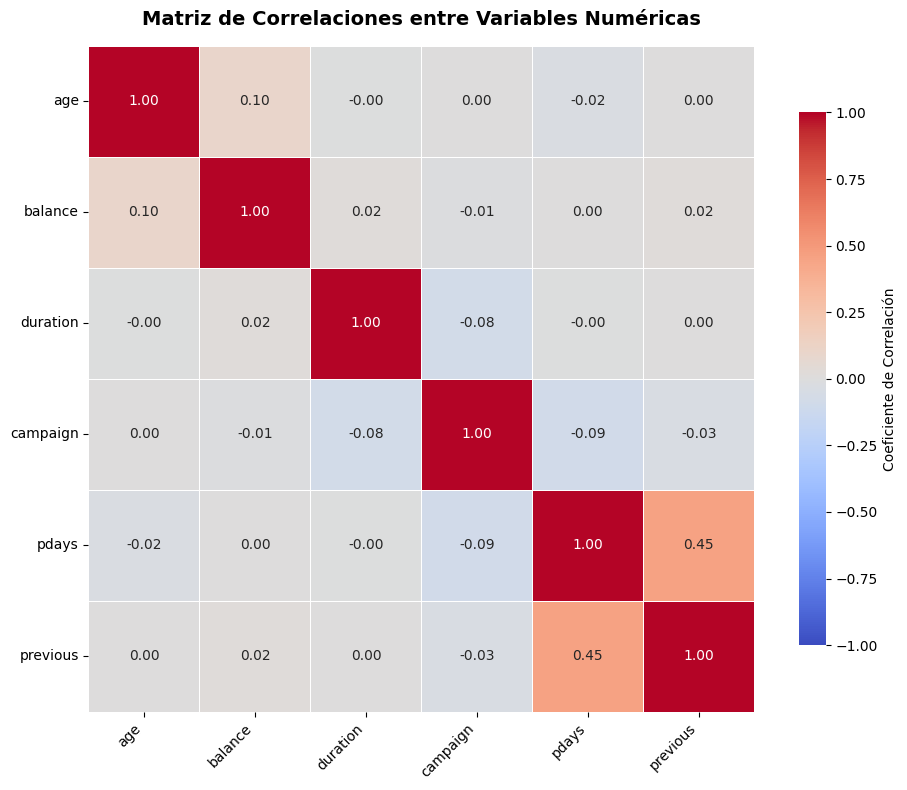


Correlaciones fuertes (|r| > 0.5):


In [21]:
# Seleccionar columnas numéricas
columnas_numericas = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

# Calcular correlación
correlacion = df[columnas_numericas].corr()

# Configuración del gráfico
plt.figure(figsize=(10, 8))

# Crear heatmap
sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de Correlación"},
    vmin=-1,
    vmax=1
)

plt.title('Matriz de Correlaciones entre Variables Numéricas', fontsize=14, weight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Identificar correlaciones fuertes (|r| > 0.5) excluyendo la diagonal
print("\nCorrelaciones fuertes (|r| > 0.5):")
for i in range(len(correlacion.columns)):
    for j in range(i+1, len(correlacion.columns)):
        valor = correlacion.iloc[i, j]
        if abs(valor) > 0.5:
            print(f"{correlacion.columns[i]} <-> {correlacion.columns[j]}: {valor:.3f}")

## Preprocesamiento de variables
Utilizaremos one-hot encoding para codificar las variables `job, marital, contact y poutcome`

In [22]:
# One-Hot Encoding para NOMINALES (Job y Marital)
df = pd.get_dummies(df, columns=['job', 'marital'], drop_first=True)

# Verificar encoding
print(df.head())

   age education  default  balance  housing  loan  contact  day  month  \
0   58         3        0     2143        1     0  unknown    5      5   
1   44         2        0       29        1     0  unknown    5      5   
2   33         2        0        2        1     1  unknown    5      5   
3   47         0        0     1506        1     0  unknown    5      5   
4   33         0        0        1        0     0  unknown    5      5   

   duration  ...  job_management  job_retired  job_self-employed job_services  \
0       261  ...            True        False              False        False   
1       151  ...           False        False              False        False   
2        76  ...           False        False              False        False   
3        92  ...           False        False              False        False   
4       198  ...           False        False              False        False   

   job_student  job_technician  job_unemployed  job_unknown  marital

In [23]:
# One-Hot Encoding para NOMINALES (contact y poutcome)
df = pd.get_dummies(df, columns=['contact', 'poutcome'], drop_first=True)

# Verificar encoding
print(df.head())

   age education  default  balance  housing  loan  day  month  duration  \
0   58         3        0     2143        1     0    5      5       261   
1   44         2        0       29        1     0    5      5       151   
2   33         2        0        2        1     1    5      5        76   
3   47         0        0     1506        1     0    5      5        92   
4   33         0        0        1        0     0    5      5       198   

   campaign  ...  job_technician  job_unemployed  job_unknown  \
0         1  ...           False           False        False   
1         1  ...            True           False        False   
2         1  ...           False           False        False   
3         1  ...           False           False        False   
4         1  ...           False           False         True   

   marital_married  marital_single  contact_telephone  contact_unknown  \
0             True           False              False             True   
1         

### Matriz de correlación de variables después de one-hot enconding

Correlaciones fuertes (|r| > 0.5):

pdays <-> poutcome_unknown: -0.870

previous <-> poutcome_unknown: -0.533

marital_married <-> marital_single: -0.772

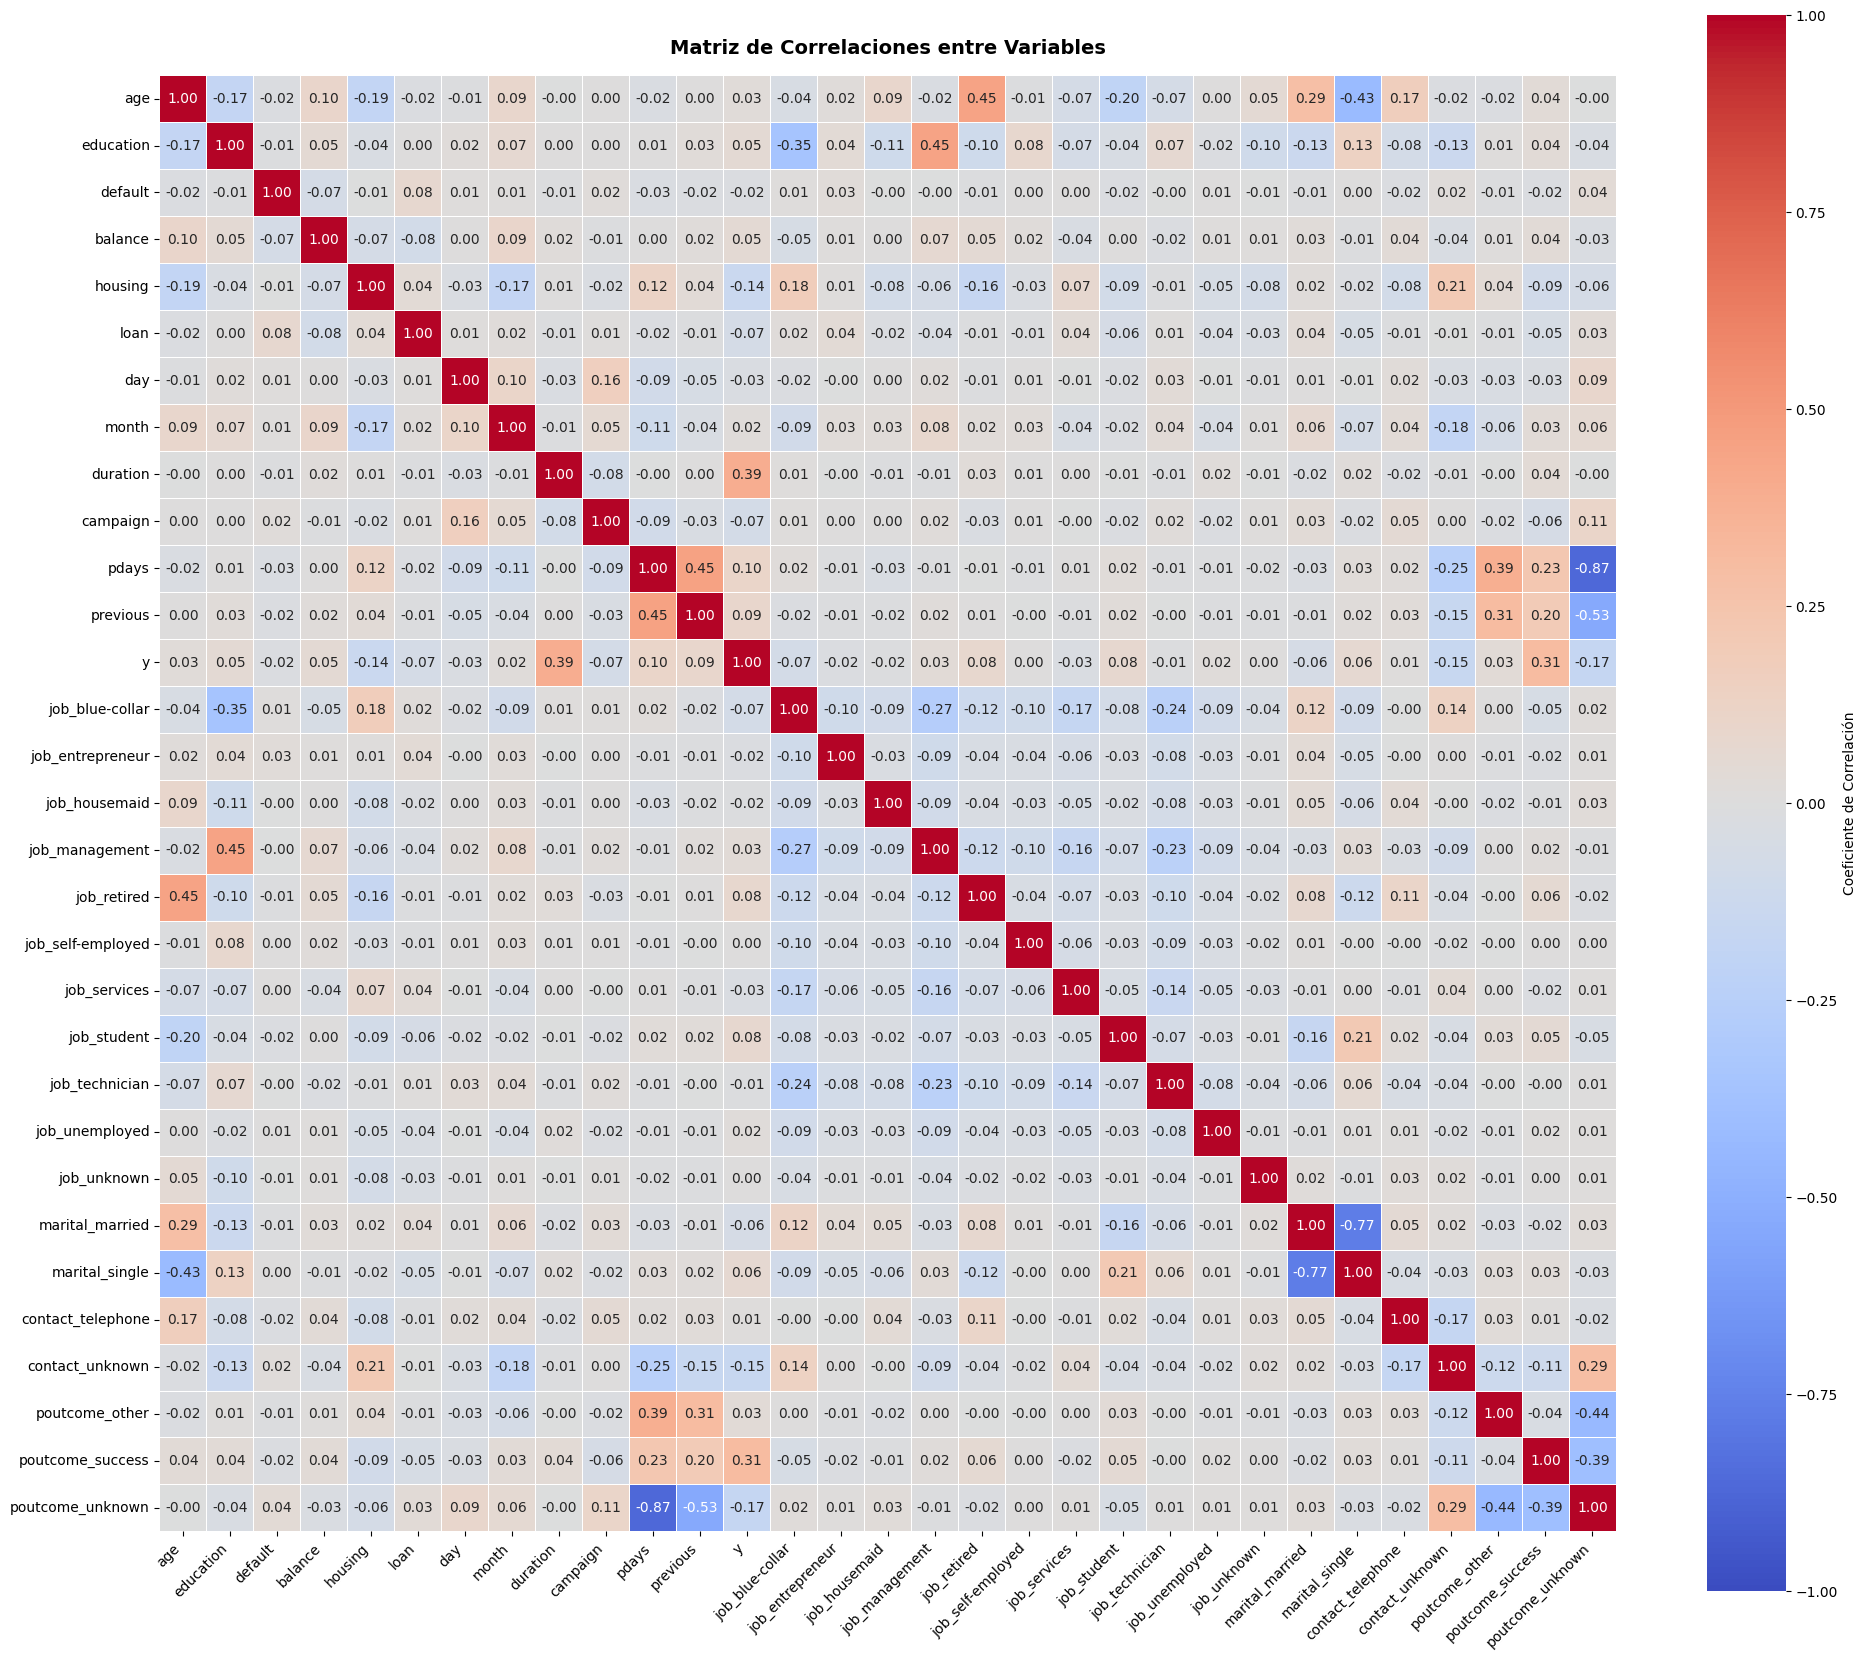


Correlaciones fuertes (|r| > 0.5):
pdays <-> poutcome_unknown: -0.870
previous <-> poutcome_unknown: -0.533
marital_married <-> marital_single: -0.772


In [24]:
# Calcular correlación
matriz_corr = df.corr()

# Configuración del gráfico
plt.figure(figsize=(20, 20))

# Crear heatmap
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de Correlación"},
    vmin=-1,
    vmax=1
)

plt.title('Matriz de Correlaciones entre Variables', fontsize=14, weight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Identificar correlaciones fuertes (|r| > 0.5) excluyendo la diagonal
print("\nCorrelaciones fuertes (|r| > 0.5):")
for i in range(len(matriz_corr.columns)):
    for j in range(i+1, len(matriz_corr.columns)):
        valor = matriz_corr.iloc[i, j]
        if abs(valor) > 0.5:
            print(f"{matriz_corr.columns[i]} <-> {matriz_corr.columns[j]}: {valor:.3f}")

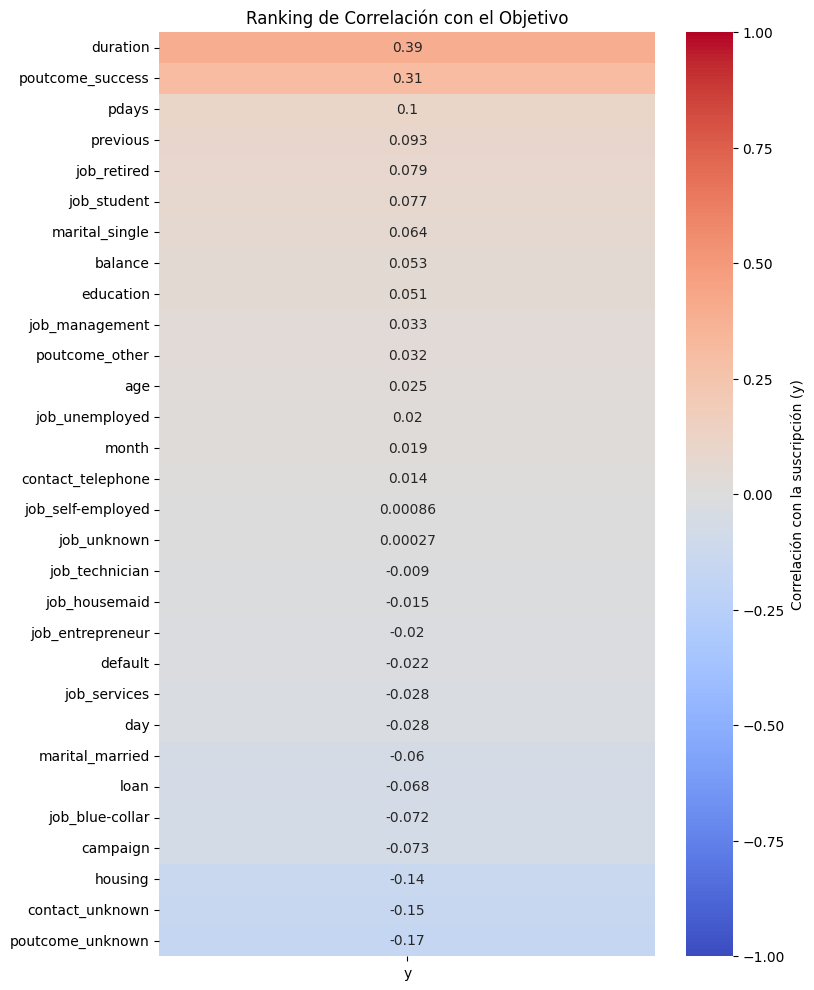

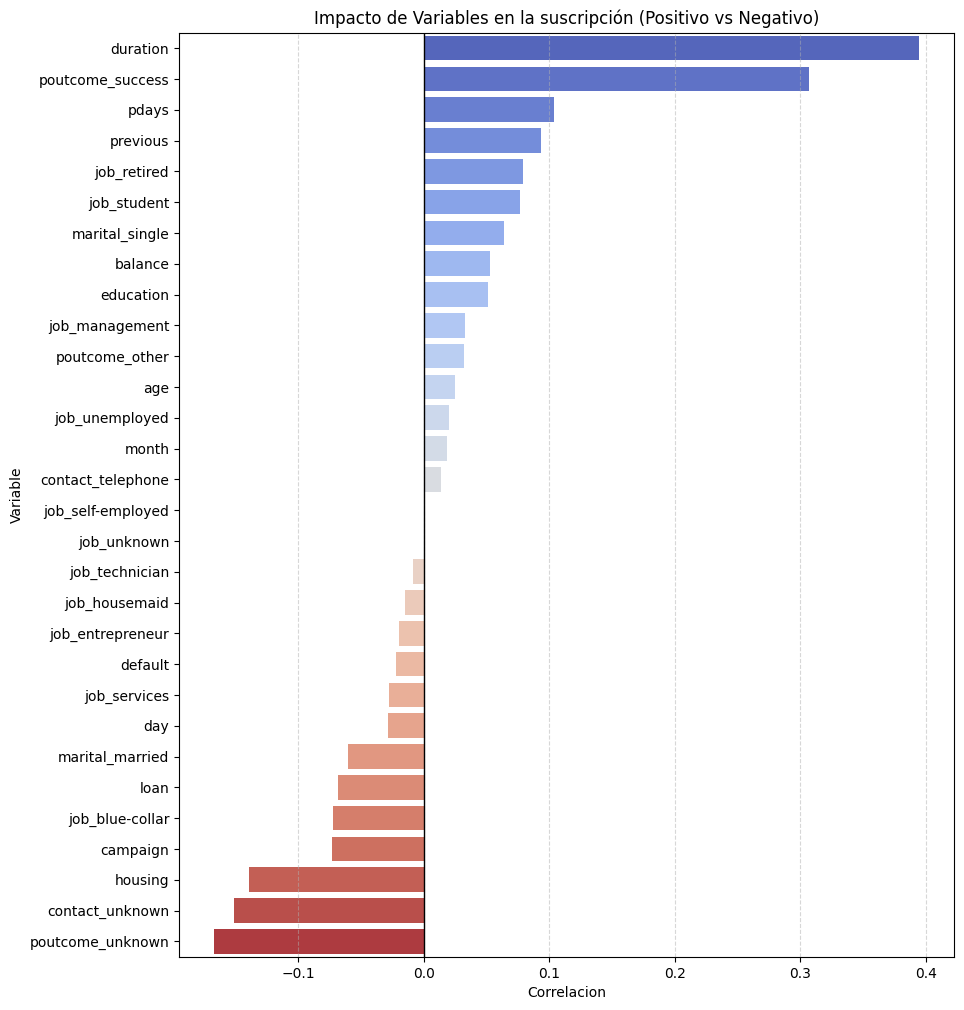

In [25]:
# Calcular la matriz completa
corr_matrix = df.corr()

# Seleccionamos solo la columna del target ('y')
# Ordenamos de mayor a menor para ver el ranking de importancia
target_corr = corr_matrix[['y']].sort_values(by='y', ascending=False)

target_corr = target_corr.drop('y')

# VISUALIZACIÓN: Heatmap Vertical
plt.figure(figsize=(8, 12))
sns.heatmap(target_corr,
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlación con la suscripción (y)'})
plt.title('Ranking de Correlación con el Objetivo')
plt.show()

# VISUALIZACIÓN: Barplot
plt.figure(figsize=(10, 12))
# Convertimos a formato simple para graficar
corr_data = target_corr.reset_index()
corr_data.columns = ['Variable', 'Correlacion']

sns.barplot(x='Correlacion', y='Variable', hue='Variable', legend=False, data=corr_data, palette='coolwarm')
plt.title('Impacto de Variables en la suscripción (Positivo vs Negativo)')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# **6. Análisis Predictivo**

## Preprocesamiento para Análisis Predictivo: Problemas, Técnicas y Código


In [26]:
print(df_orig.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


### Clase desbalanceada `y`
Podemos notar que la clase `y` (suscripción) se encuentra fuertemente desbalanceada

In [27]:
print(df_orig.groupby('y').size())

y
no     39922
yes     5289
dtype: int64


### Feature Enginnering

In [28]:
# Columnas numericas
cols_num = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Columnas categoricas y binarias
cols_cat = ['job', 'marital', 'education', 'contact', 'month', 'default', 'housing', 'loan', 'poutcome']

In [29]:
# One-Hot Encoding
cols_new_cat = pd.get_dummies(df_orig[cols_cat], drop_first=True)
cols_new_cat.head()

df2 = pd.concat([df_orig, cols_new_cat], axis=1)

print(df2.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day  ... default_no  default_yes  housing_no  housing_yes  \
0  unknown    5  ...       True        False       False         True   
1  unknown    5  ...       True        False       False         True   
2  unknown    5  ...       True        False       False         True   
3  unknown    5  ...       True        False       False         True   
4  unknown    5  ...       True        False        True        False   

   loan_no loan_yes poutcome_failure  poutcome_other  poutcome_success  \
0     True    False            False      

In [30]:
# Crear lista de columnas categoricas
cols_all_cat = list(cols_new_cat.columns)

In [84]:
cols_input = cols_num + cols_all_cat
df_encoded = df2[cols_input + ['y']]

In [85]:
# Mapeo de valores
df_encoded['y'] = df_encoded['y'].map(diccionario_binario)
df_encoded.head()

,age,balance,day,duration,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,...,default_yes,housing_no,housing_yes,loan_no,loan_yes,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,y
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,True,True,False,False,False,False,True,0
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,True,True,False,False,False,False,True,0
2,33,2,5,76,1,-1,0,False,False,True,...,False,False,True,False,True,False,False,False,True,0
3,47,1506,5,92,1,-1,0,False,True,False,...,False,False,True,True,False,False,False,False,True,0
4,33,1,5,198,1,-1,0,False,False,False,...,False,True,False,True,False,False,False,False,True,0


In [86]:
# Separación de variables independientes y dependientes
X = df_encoded.iloc[:, :-1]
y = df_encoded.iloc[:, -1]

In [87]:
# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [88]:
skf = StratifiedKFold(n_splits=5, shuffle= True, random_state=42)

## - Modelado Predictivo
Analizamos tratando la clase desbalanceada con SMOTE para observar el comportamiento de los modelos:

KNN Accuracy con SMOTE: 83.09%

Logistic Regression Accuracy con SMOTE: 84.72%

RandomForest Accuracy con SMOTE: 89.78%

XGBoost Accuracy con SMOTE: 90.56%

DecisionTree Accuracy con SMOTE: 86.31%

NaiveBayes Accuracy con SMOTE: 82.63%


In [89]:
# Modelos de referencia
baseline_model_dict = {}

In [48]:
# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# KFold estratificado
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline con scaling + SMOTE + modelo
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

# Evaluación con CV
knn_results = cross_val_score(knn_pipeline, X_train, y_train, cv=skf, scoring='accuracy')

print("KNN Accuracy con SMOTE: %.2f%%" % (knn_results.mean() * 100.0))


KNN Accuracy con SMOTE: 83.09%


In [49]:
knn_results = cross_validate(
    knn_pipeline, X_train, y_train, cv=skf,
    scoring=['accuracy','precision','recall','f1'],
    return_train_score=False
)

for metric in knn_results:
    print(metric, knn_results[metric].mean())


fit_time 0.16149063110351564
score_time 2.4041532039642335
test_accuracy 0.8309476701070351
test_precision 0.3736161245108832
test_recall 0.6580078053762264
test_f1 0.4765128538825697


In [51]:
# Pipeline con escalado + SMOTE + Regresión Logística
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(max_iter=1000))
])

# Evaluación con CV
lr_results = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print("Logistic Regression Accuracy con SMOTE: %.2f%%" % (lr_results.mean() * 100.0))

baseline_model_dict['Logistic Regression'] = lr_results.mean() * 100.0


Logistic Regression Accuracy con SMOTE: 84.72%


In [52]:
lr_results = cross_validate(
    lr_pipeline, X_train, y_train, cv=skf,
    scoring=['accuracy','precision','recall','f1'],
    return_train_score=False
)

for metric in lr_results:
    print(metric, lr_results[metric].mean())

fit_time 0.23100900650024414
score_time 0.021697187423706056
test_accuracy 0.8471574489604636
test_precision 0.4205518939510718
test_recall 0.8117113469745048
test_f1 0.5540369513581949


In [53]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

rf_results = cross_val_score(
    rf_pipeline, X_train, y_train,
    cv=skf, scoring='accuracy'
)

print("RandomForest Accuracy con SMOTE: %.2f%%" % (rf_results.mean()*100))
baseline_model_dict['RandForest'] = rf_results.mean() * 100.0


RandomForest Accuracy con SMOTE: 89.78%


In [54]:
# Metricas para Random Forest
rf_results = cross_validate(
    rf_pipeline, X_train, y_train, cv=skf,
    scoring=['accuracy','precision','recall','f1'],
    return_train_score=False
)

for metric in rf_results:
    print(metric, rf_results[metric].mean())

fit_time 11.637893056869506
score_time 0.16840286254882814
test_accuracy 0.8978416861424516
test_precision 0.5625596445437007
test_recall 0.5675212459422985
test_f1 0.5649555199142087


In [55]:
# Modelo XGBoost

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_results = cross_val_score(
    xgb_pipeline, X_train, y_train,
    cv=skf, scoring='accuracy'
)

print("XGBoost Accuracy con SMOTE: %.2f%%" % (xgb_results.mean()*100))
baseline_model_dict['XGBoost'] = xgb_results.mean() * 100.0


XGBoost Accuracy con SMOTE: 90.56%


In [56]:
# Metricas para XGBoost

xgb_results = cross_validate(
    xgb_pipeline, X_train, y_train, cv=skf,
    scoring=['accuracy','precision','recall','f1'],
    return_train_score=False
)

for metric in xgb_results:
    print(metric, xgb_results[metric].mean())

fit_time 2.358772039413452
score_time 0.05090422630310058
test_accuracy 0.9056148919053371
test_precision 0.5997962706716746
test_recall 0.5810307473465368
test_f1 0.5902061341726664


In [57]:
# Modelo DecisionTreeClassifier

dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

dt_results = cross_val_score(
    dt_pipeline, X_train, y_train,
    cv=skf, scoring='accuracy'
)

print("DecisionTree Accuracy con SMOTE: %.2f%%" % (dt_results.mean()*100))
baseline_model_dict['DecTree'] = dt_results.mean() * 100.0

DecisionTree Accuracy con SMOTE: 86.31%


In [58]:
# Metricas DecisionTreeClassifier

dt_results = cross_validate(
    dt_pipeline, X_train, y_train, cv=skf,
    scoring=['accuracy','precision','recall','f1'],
    return_train_score=False
)

for metric in dt_results:
    print(metric, dt_results[metric].mean())

fit_time 1.2889639377593993
score_time 0.025095081329345702
test_accuracy 0.8630517163526953
test_precision 0.43343495024722334
test_recall 0.5559076485392275
test_f1 0.48703740082039115


In [59]:
# Modelo Naive bayes - GaussianNB

nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('nb', GaussianNB())
])

nb_results = cross_val_score(
    nb_pipeline, X_train, y_train,
    cv=skf, scoring='accuracy'
)

print("NaiveBayes Accuracy con SMOTE: %.2f%%" % (nb_results.mean()*100))
baseline_model_dict['NaiBayes'] = nb_results.mean() * 100.0

NaiveBayes Accuracy con SMOTE: 82.63%


In [60]:
# Modelo Naive bayes - GaussianNB

nb_results = cross_validate(
    nb_pipeline, X_train, y_train, cv=skf,
    scoring=['accuracy','precision','recall','f1'],
    return_train_score=False
)

for metric in nb_results:
    print(metric, nb_results[metric].mean())

fit_time 0.16776280403137206
score_time 0.022664546966552734
test_accuracy 0.8262710055795222
test_precision 0.35623106661905074
test_recall 0.6004748878433089
test_f1 0.44709850427648873


In [62]:
#Resumen de test
results_dict = {
    'KNN': knn_results['test_accuracy'].mean()*100,
    'Logistic Regression': lr_results['test_accuracy'].mean()*100,
    'RandomForest': rf_results['test_accuracy'].mean()*100,
    'XGBoost': xgb_results['test_accuracy'].mean()*100,
    #'SVM': svm_results.mean()*100,
    'DecisionTree': dt_results['test_accuracy'].mean()*100,
    'NaiveBayes': nb_results['test_accuracy'].mean()*100
}

for model, score in results_dict.items():
    print(f"{model}: {score:.2f}%")

KNN: 83.09%
Logistic Regression: 84.72%
RandomForest: 89.78%
XGBoost: 90.56%
DecisionTree: 86.31%
NaiveBayes: 82.63%


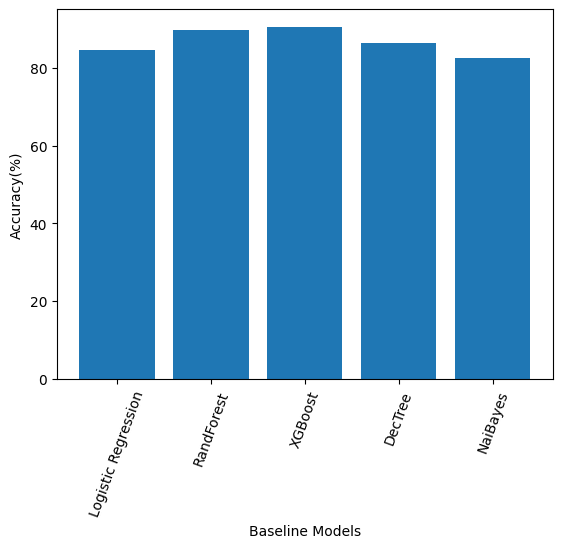

In [64]:
# Grafico de Accuracies
keys = list(baseline_model_dict.keys())
values = list(baseline_model_dict.values())

fig1, ax1 = plt.subplots()

# Crear el bar plot
ax1.bar(keys, values)

# Etiquetas
ax1.set_xlabel('Baseline Models')
ax1.set_ylabel('Accuracy(%)')

ax1.set_xticks(range(len(keys)))
ax1.set_xticklabels(keys, rotation=70)

plt.show()

In [90]:
# Diccionarios para mejores parametros y scores
params_model_dict = {}
score_model_dict = {}


# NUEVO ANALISIS
Se determino eliminar la columna `duration` derivado que en el escenario real es una variable que se va a desconocer antes de hacer una llamada.

In [93]:
# Mapeo de valores
df_encoded = df_encoded.drop(columns=['duration'])
df_encoded.head()

,age,balance,day,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,default_yes,housing_no,housing_yes,loan_no,loan_yes,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,y
0,58,2143,5,1,-1,0,False,False,False,False,...,False,False,True,True,False,False,False,False,True,0
1,44,29,5,1,-1,0,False,False,False,False,...,False,False,True,True,False,False,False,False,True,0
2,33,2,5,1,-1,0,False,False,True,False,...,False,False,True,False,True,False,False,False,True,0
3,47,1506,5,1,-1,0,False,True,False,False,...,False,False,True,True,False,False,False,False,True,0
4,33,1,5,1,-1,0,False,False,False,False,...,False,True,False,True,False,False,False,False,True,0


In [94]:
# Separación de variables independientes y dependientes
X = df_encoded.iloc[:, :-1]
y = df_encoded.iloc[:, -1]

In [95]:
# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [96]:
skf = StratifiedKFold(n_splits=5, shuffle= True, random_state=42)

## - Modelado Predictivo sin columna "Duration"
Analizamos nuevamente el comportamiento de los modelos:

KNN Accuracy con SMOTE: 74.89%

Logistic Regression Accuracy con SMOTE: 74.19%

RandomForest Accuracy con SMOTE: 87.79%

XGBoost Accuracy con SMOTE: 88.92%

DecisionTree Accuracy con SMOTE: 81.62%

NaiveBayes Accuracy con SMOTE: 80.75%




In [98]:
# Modelos de referencia
baseline_model_dict = {}

In [99]:
# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# KFold estratificado
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline con scaling + SMOTE + modelo
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

# Evaluación con CV
knn_results = cross_val_score(knn_pipeline, X_train, y_train, cv=skf, scoring='accuracy')

print("KNN Accuracy con SMOTE: %.2f%%" % (knn_results.mean() * 100.0))


KNN Accuracy con SMOTE: 74.89%


In [100]:
knn_results = cross_validate(
    knn_pipeline, X_train, y_train, cv=skf,
    scoring=['accuracy','precision','recall','f1'],
    return_train_score=False
)

for metric in knn_results:
    print(metric, knn_results[metric].mean())


fit_time 0.15505356788635255
score_time 2.3588746070861815
test_accuracy 0.7488548238418055
test_precision 0.24132609609104771
test_recall 0.5348356858883174
test_f1 0.3325045090375098


In [101]:
# Pipeline con escalado + SMOTE + Regresión Logística
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(max_iter=1000))
])

# Evaluación con CV
lr_results = cross_val_score(
    lr_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print("Logistic Regression Accuracy con SMOTE: %.2f%%" % (lr_results.mean() * 100.0))

baseline_model_dict['Logistic Regression'] = lr_results.mean() * 100.0


Logistic Regression Accuracy con SMOTE: 74.19%


In [102]:
lr_results = cross_validate(
    lr_pipeline, X_train, y_train, cv=skf,
    scoring=['accuracy','precision','recall','f1'],
    return_train_score=False
)

for metric in lr_results:
    print(metric, lr_results[metric].mean())

fit_time 0.23150315284729003
score_time 0.019074773788452147
test_accuracy 0.74190314800074
test_precision 0.2555037846034955
test_recall 0.6301947696684539
test_f1 0.36354900434326815


In [103]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

rf_results = cross_val_score(
    rf_pipeline, X_train, y_train,
    cv=skf, scoring='accuracy'
)

print("RandomForest Accuracy con SMOTE: %.2f%%" % (rf_results.mean()*100))
baseline_model_dict['RandForest'] = rf_results.mean() * 100.0


RandomForest Accuracy con SMOTE: 87.79%


In [104]:
# Metricas para Random Forest
rf_results = cross_validate(
    rf_pipeline, X_train, y_train, cv=skf,
    scoring=['accuracy','precision','recall','f1'],
    return_train_score=False
)

for metric in rf_results:
    print(metric, rf_results[metric].mean())

fit_time 9.330039501190186
score_time 0.20343213081359862
test_accuracy 0.8778714445927956
test_precision 0.46579322088245023
test_recall 0.3036163694058431
test_f1 0.3672915368076962


In [105]:
# Modelo XGBoost

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_results = cross_val_score(
    xgb_pipeline, X_train, y_train,
    cv=skf, scoring='accuracy'
)

print("XGBoost Accuracy con SMOTE: %.2f%%" % (xgb_results.mean()*100))
baseline_model_dict['XGBoost'] = xgb_results.mean() * 100.0


XGBoost Accuracy con SMOTE: 88.92%


In [106]:
# Metricas para XGBoost

xgb_results = cross_validate(
    xgb_pipeline, X_train, y_train, cv=skf,
    scoring=['accuracy','precision','recall','f1'],
    return_train_score=False
)

for metric in xgb_results:
    print(metric, xgb_results[metric].mean())

fit_time 2.4710794925689696
score_time 0.049306058883666994
test_accuracy 0.8892154996546651
test_precision 0.5485340820636219
test_recall 0.29956450377503013
test_f1 0.38724955849257736


In [107]:
# Modelo DecisionTreeClassifier

dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

dt_results = cross_val_score(
    dt_pipeline, X_train, y_train,
    cv=skf, scoring='accuracy'
)

print("DecisionTree Accuracy con SMOTE: %.2f%%" % (dt_results.mean()*100))
baseline_model_dict['DecTree'] = dt_results.mean() * 100.0

DecisionTree Accuracy con SMOTE: 81.62%


In [108]:
# Metricas DecisionTreeClassifier

dt_results = cross_validate(
    dt_pipeline, X_train, y_train, cv=skf,
    scoring=['accuracy','precision','recall','f1'],
    return_train_score=False
)

for metric in dt_results:
    print(metric, dt_results[metric].mean())

fit_time 0.7658639430999756
score_time 0.020734310150146484
test_accuracy 0.8162228783625215
test_precision 0.27271777278217224
test_recall 0.3435897435897436
test_f1 0.30390732788514885


In [109]:
# Modelo Naive bayes - GaussianNB

nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('nb', GaussianNB())
])

nb_results = cross_val_score(
    nb_pipeline, X_train, y_train,
    cv=skf, scoring='accuracy'
)

print("NaiveBayes Accuracy con SMOTE: %.2f%%" % (nb_results.mean()*100))
baseline_model_dict['NaiBayes'] = nb_results.mean() * 100.0

NaiveBayes Accuracy con SMOTE: 80.75%


In [110]:
# Modelo Naive bayes - GaussianNB

nb_results = cross_validate(
    nb_pipeline, X_train, y_train, cv=skf,
    scoring=['accuracy','precision','recall','f1'],
    return_train_score=False
)

for metric in nb_results:
    print(metric, nb_results[metric].mean())

fit_time 0.16681294441223143
score_time 0.021250486373901367
test_accuracy 0.8075332810650939
test_precision 0.3094869219776525
test_recall 0.5232213590108327
test_f1 0.3887446084286986


In [111]:
#Resumen de test
results_dict = {
    'KNN': knn_results['test_accuracy'].mean()*100,
    'Logistic Regression': lr_results['test_accuracy'].mean()*100,
    'RandomForest': rf_results['test_accuracy'].mean()*100,
    'XGBoost': xgb_results['test_accuracy'].mean()*100,
    #'SVM': svm_results.mean()*100,
    'DecisionTree': dt_results['test_accuracy'].mean()*100,
    'NaiveBayes': nb_results['test_accuracy'].mean()*100
}

for model, score in results_dict.items():
    print(f"{model}: {score:.2f}%")

KNN: 74.89%
Logistic Regression: 74.19%
RandomForest: 87.79%
XGBoost: 88.92%
DecisionTree: 81.62%
NaiveBayes: 80.75%


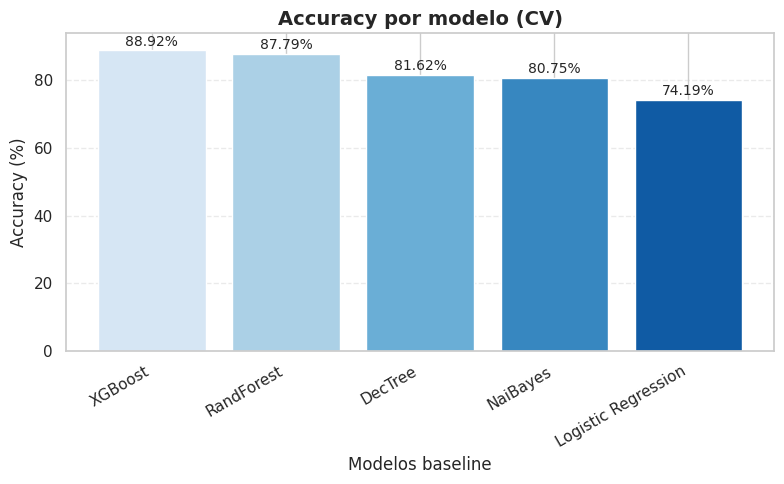

In [114]:
# Grafico de Accuracies

# Datos
keys = list(baseline_model_dict.keys())
values = list(baseline_model_dict.values())

# Ordenar por accuracy descendente
pairs = sorted(zip(keys, values), key=lambda x: x[1], reverse=True)
sorted_keys, sorted_values = zip(*pairs)

# Estilo y figura
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))

# Paleta
palette = sns.color_palette("Blues", n_colors=len(sorted_keys))

# Barras
bars = ax.bar(range(len(sorted_keys)), sorted_values, color=palette)

# Ejes y títulos
ax.set_title("Accuracy por modelo (CV)", fontsize=14, weight="bold")
ax.set_xlabel("Modelos baseline")
ax.set_ylabel("Accuracy (%)")

# Rejilla
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Definir ticks y etiquetas correctamente (sin warning)
ax.set_xticks(range(len(sorted_keys)))
ax.set_xticklabels(sorted_keys, rotation=30, ha="right")

# Límites del eje Y (con pequeño margen)
ymax = max(sorted_values)
ax.set_ylim(0, min(100, ymax + 5))

# Etiquetas de valor encima de cada barra
for bar, val in zip(bars, sorted_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.2f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()



### - Modelo elegido y parámetros
Se eligieron dos modelos para optimizar los hiperparametros
- XGBoost
- Random Forest

In [115]:
# Configuración del Modelo XGBoost GridSearchCV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_param_grid = {
    'xgb__n_estimators': [50, 100],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

# Asumiendo que X_train y y_train ya están definidos
xgb_grid.fit(X_train, y_train)

# RESULTADOS

# Guardamos los resultados en el diccionario bajo la llave 'XGBoost'
params_model_dict['XGBoost'] = {
    'best_params': xgb_grid.best_params_,
    'best_score': xgb_grid.best_score_
}

# Mejores parametros y score
print(f"Mejores parámetros: {params_model_dict['XGBoost']['best_params']}")
print(f"Mejor F1 Score: {params_model_dict['XGBoost']['best_score']}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores parámetros: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 7, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}
Mejor F1 Score: 0.4292435022230114


In [116]:
# Modelo RandomForestClassifier GridSearchCV

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [5, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

params_model_dict['RandomForest'] = {
    'best_params': rf_grid.best_params_,
    'best_score': rf_grid.best_score_
}

#  Mejores parametros y score
print(f"Mejores parámetros: {params_model_dict['RandomForest']['best_params']}")
print(f"Mejor F1 Score: {params_model_dict['RandomForest']['best_score']}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores parámetros: {'rf__max_depth': 20, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}
Mejor F1 Score: 0.4400135810278769


# Resultados

### GridSearchCV
XGBoost: Mejores parámetros: `{'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 7, 'xgb__n_estimators': 100, 'xgb__subsample': 0.8}`

Random Forest: Mejores parámetros: `{'rf__max_depth': 20, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 50} `




# CONCLUSIONES
El objetivo de este proyecto fue desarrollar un modelo predictivo capaz de identificar clientes bancarios que son propensos a suscribir un depósito a plazo. Se identificó que la variable `duration` inflaba las métricas al utilizarla como predictor, por lo cual se decidio eliminarla y observar nuevamente el comportamiento de los modelos, como era de esperarse estos redujeron el porcentaje predictivo, sin embargo, se apega más a un excenario real donde no se puede conocer con anticipación la duración de una llamada con un cliente.

Se realizo el manejo de la clase desbalanceada `y` utilizando SMOTE dentro del entrenamiento.

Se optimizaron parametros utilizando el `GridSearch`, el cual tomo bastante tiempo para dar el resultado, aproximadamente 25 minutos, debido a que prueba todas las combinaciones posibles. Se obtuvo un mejor resultado de F1 utilizando el modelo de Random Forest con el 44%.
